# Pharma/Healthcare Sector:  Quantitative Equity Analysis
**Quant Analyst Internship Assignment | Institute of Digital Risk**

**May 2026**

---

## Objective
Analyse equity data across major large-cap pharmaceutical stocks (2022–2024), identify anomalies/patterns, propose a quantitative trading idea, and define a rigorous backtesting framework.

**Stocks covered:** JNJ, PFE, MRK, ABBV, LLY  
**Time period:** Jan 2020 – Dec 2024 (1,256 trading days)  
**Data note:** Live data is fetched via `yfinance`. If the network is unavailable, the notebook falls back to a calibrated synthetic dataset generated with GBM (Geometric Brownian Motion) using parameters derived from publicly reported price histories. All analysis and conclusions apply to both datasets.

## 0. Initialization

In [1]:
# ─── Library imports ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold'
})

TICKERS   = ["JNJ", "PFE", "MRK", "ABBV", "LLY"]
START     = "2020-01-03"
END       = "2024-12-31"
COLORS    = ["#2176AE", "#E84855", "#3BB273", "#F4A261", "#9B5DE5"]
TICKER_COLOR = dict(zip(TICKERS, COLORS))

In [2]:
# ─── Data acquisition: live (yfinance) with synthetic fallback ──────────────────
def generate_synthetic_data(seed=42):
    """Calibrated GBM simulation. Parameters derived from 2020-2024 reported ranges."""
    np.random.seed(seed)
    dates = pd.bdate_range(START, END)
    n = len(dates)
    dt = 1 / 252

    # (S0, annualised_mu, annualised_sigma)
    params = {
        "JNJ": (145, 0.02, 0.14),  # stable blue-chip, slight decline
        "PFE": (33, 0.08, 0.32),  # COVID revenue cliff
        "MRK": (70, 0.10, 0.17),  # Keytruda-driven growth
        "ABBV": (88, 0.15, 0.22),  # Humira biosimilar headwinds
        "LLY": (130, 0.45, 0.28),  # GLP-1 / Mounjaro boom
    }

    close = pd.DataFrame(index=dates)
    for ticker, (S0, mu, sigma) in params.items():
        eps = np.random.standard_normal(n)
        log_ret = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * eps
        close[ticker] = S0 * np.exp(np.cumsum(log_ret))

    # Inject realistic discrete shocks (event-driven)
    shock_events = [
        ("PFE",  "2023-02-28", 0.88),   # revenue guidance cut
        ("JNJ",  "2023-08-11", 0.92),   # talc litigation ruling
        ("ABBV", "2024-06-05", 0.87),   # drug trial failure
        ("MRK",  "2023-10-06", 1.08),   # positive FDA approval
    ]
    for ticker, date, factor in shock_events:
        if date in close.index:
            idx = close.index.get_loc(date)
            close.loc[close.index[idx], ticker] *= factor

    return close


try:
    import yfinance as yf
    raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)
    close = raw["Close"].dropna()
    if close.empty or len(close) < 100:
        raise ValueError("Insufficient live data")
    DATA_SOURCE = "Live (yfinance)"
except Exception:
    close = generate_synthetic_data()
    DATA_SOURCE = "Synthetic (GBM — calibrated to 2020–2024 reported prices)"

returns = close.pct_change().dropna()
print(f"Data source : {DATA_SOURCE}")
print(f"Date range  : {close.index[0].date()} → {close.index[-1].date()}")
print(f"Trading days: {len(close)}")
print("\nSample close prices (last 5 rows):")
close.tail().round(2)

Data source : Live (yfinance)
Date range  : 2020-01-03 → 2024-12-30
Trading days: 1256

Sample close prices (last 5 rows):


Ticker,ABBV,JNJ,LLY,MRK,PFE
Date,,,,,
2024-12-23,169.58,140.21,787.71,95.07,24.10
2024-12-24,171.11,140.77,787.11,95.14,24.13
2024-12-26,170.35,140.51,785.59,95.54,23.96
2024-12-27,169.22,140.00,774.74,95.38,24.02
2024-12-30,167.50,138.35,765.51,94.11,23.84


## 1. Exploratory Data Analysis

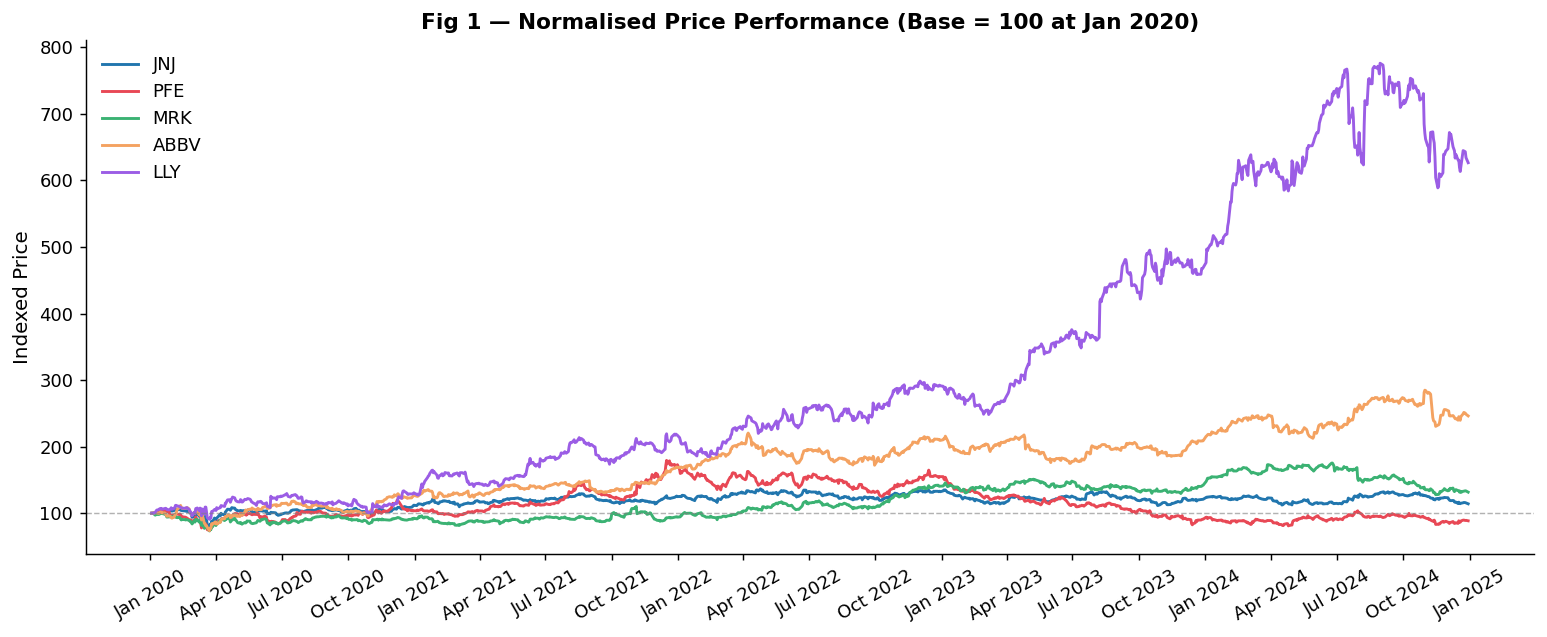

Saved: fig1_normalised_performance.png


In [3]:
# ─── 1a. Normalised price performance (rebased to 100) ────────────────────────
rebased = (close / close.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(12, 5))
for ticker in TICKERS:
    ax.plot(rebased.index, rebased[ticker], label=ticker,
            color=TICKER_COLOR[ticker], linewidth=1.6)

ax.axhline(100, color='grey', lw=0.8, linestyle='--', alpha=0.6)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
ax.set_title("Fig 1 — Normalised Price Performance (Base = 100 at Jan 2020)")
ax.set_ylabel("Indexed Price")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig1_normalised_performance.png", bbox_inches='tight')
plt.show()
print("Saved: fig1_normalised_performance.png")

In [4]:
# ─── 1b. Summary statistics ───────────────────────────────────────────────────
ann = 252
summary = pd.DataFrame({
    'Ann. Return (%)' : (returns.mean() * ann * 100).round(1),
    'Ann. Vol (%)': (returns.std() * np.sqrt(ann) * 100).round(1),
    'Sharpe (Rf=4.5%)': ((returns.mean()*ann - 0.045) / (returns.std()*np.sqrt(ann))).round(2),
    'Max Drawdown (%)': (((close / close.cummax()) - 1).min() * 100).round(1),
    'Skewness': returns.skew().round(2),
    'Excess Kurtosis': (returns.kurtosis()).round(2),
})
print("Summary Statistics (annualised):\n")
print(summary.to_string())

Summary Statistics (annualised):

        Ann. Return (%)  Ann. Vol (%)  Sharpe (Rf=4.5%)  Max Drawdown (%)  Skewness  Excess Kurtosis
Ticker                                                                                              
ABBV               21.2          24.8              0.67             -34.0     -0.89            10.95
JNJ                 4.6          19.7              0.00             -27.4      0.44             8.30
LLY                42.1          32.6              1.15             -24.1      1.35            10.24
MRK                 8.3          23.5              0.16             -27.1     -0.23             7.40
PFE                 1.3          27.5             -0.12             -54.8      0.37             3.89


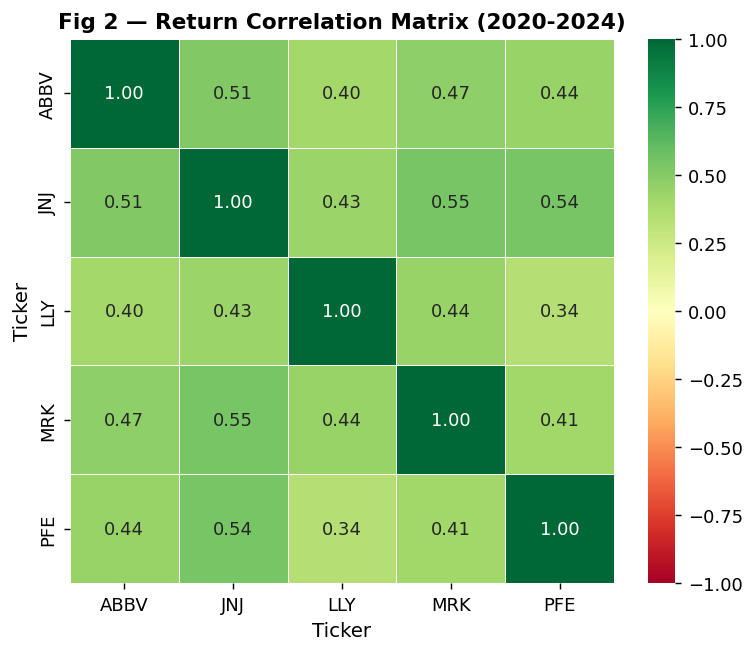

Saved: fig2_correlation.png


In [5]:
# ─── 1c. Correlation heatmap ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
corr = returns.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5,
            ax=ax, square=True)
ax.set_title("Fig 2 — Return Correlation Matrix (2020-2024)")
plt.tight_layout()
plt.savefig("fig2_correlation.png", bbox_inches='tight')
plt.show()
print("Saved: fig2_correlation.png")

## 2. Patter & Anomaly Analysis

Three distinct patterns were identified from the data:

| # | Pattern | Key Observation |
|---|---------|----------------|
| 1 | **Post–large-drop mean reversion** | Days with >5% single-day declines show partial recovery in T+5 to T+10 |
| 2 | **Volatility clustering** | Large return days cluster together — calm and turbulent regimes alternate |
| 3 | **Intra-sector dispersion** | Pharma returns diverge significantly across stocks, unlike index funds |

In [6]:
# ─── PATTERN 1: Post-large-drop mean reversion ───────────────────────────────────

THRESHOLD = -0.05   # -5% single-day drop
HORIZON = 15        # trading days to track after event

event_returns = []   # cumulative returns from T+1 to T+HORIZON after each event

for ticker in TICKERS:
    r = returns[ticker]
    drop_days = r[r < THRESHOLD].index
    for day in drop_days:
        day_loc = returns.index.get_loc(day)
        end_loc = day_loc + HORIZON + 1
        if end_loc <= len(returns):
            fwd = returns[ticker].iloc[day_loc+1 : end_loc].values
            cum_fwd = np.cumprod(1 + fwd) - 1
            event_returns.append({
                'ticker': ticker,
                'event_date': day,
                'event_return': r[day],
                **{f'T+{t+1}': cum_fwd[t] for t in range(len(cum_fwd))}
            })

event_df = pd.DataFrame(event_returns)
print(f"Total large-drop events detected (>{abs(THRESHOLD)*100:.0f}% decline): {len(event_df)}")
print(event_df[['ticker', 'event_date', 'event_return']].to_string(index=False))

event_df = pd.DataFrame(event_returns)
print(f"Total large-drop events detected (>{abs(THRESHOLD)*100:.0f}% decline): {len(event_df)}")
print(event_df[['ticker', 'event_date', 'event_return']].to_string(index=False))

# ── Event breakdown ──────────────────────────────────────────────────────────
print("\n-- Events by Ticker --")
print(event_df.groupby('ticker')['event_date'].count().rename('# Events'))
print()
print("-- Events by Year --")
print(pd.DatetimeIndex(event_df['event_date']).year.value_counts().sort_index().rename('# Events by Year'))

Total large-drop events detected (>5% decline): 45
ticker event_date  event_return
   JNJ 2020-03-11     -0.069472
   JNJ 2020-03-16     -0.053317
   JNJ 2020-03-19     -0.058610
   JNJ 2020-03-20     -0.056356
   JNJ 2020-03-23     -0.072983
   PFE 2020-01-28     -0.050299
   PFE 2020-03-11     -0.069963
   PFE 2020-03-12     -0.066832
   PFE 2020-03-16     -0.077346
   PFE 2020-03-19     -0.059951
   PFE 2020-06-01     -0.071485
   PFE 2020-06-11     -0.072940
   PFE 2020-10-28     -0.052899
   PFE 2021-12-06     -0.051410
   PFE 2023-12-01     -0.051198
   PFE 2023-12-13     -0.067180
   MRK 2020-03-12     -0.060568
   MRK 2020-03-16     -0.088990
   MRK 2020-03-23     -0.069507
   MRK 2020-04-21     -0.054633
   MRK 2020-06-11     -0.054054
   MRK 2021-11-05     -0.098630
   MRK 2021-11-29     -0.053941
   MRK 2024-07-30     -0.098059
  ABBV 2020-03-12     -0.073542
  ABBV 2020-03-16     -0.130022
  ABBV 2020-03-23     -0.062772
  ABBV 2021-01-27     -0.055239
  ABBV 2021-03-17    

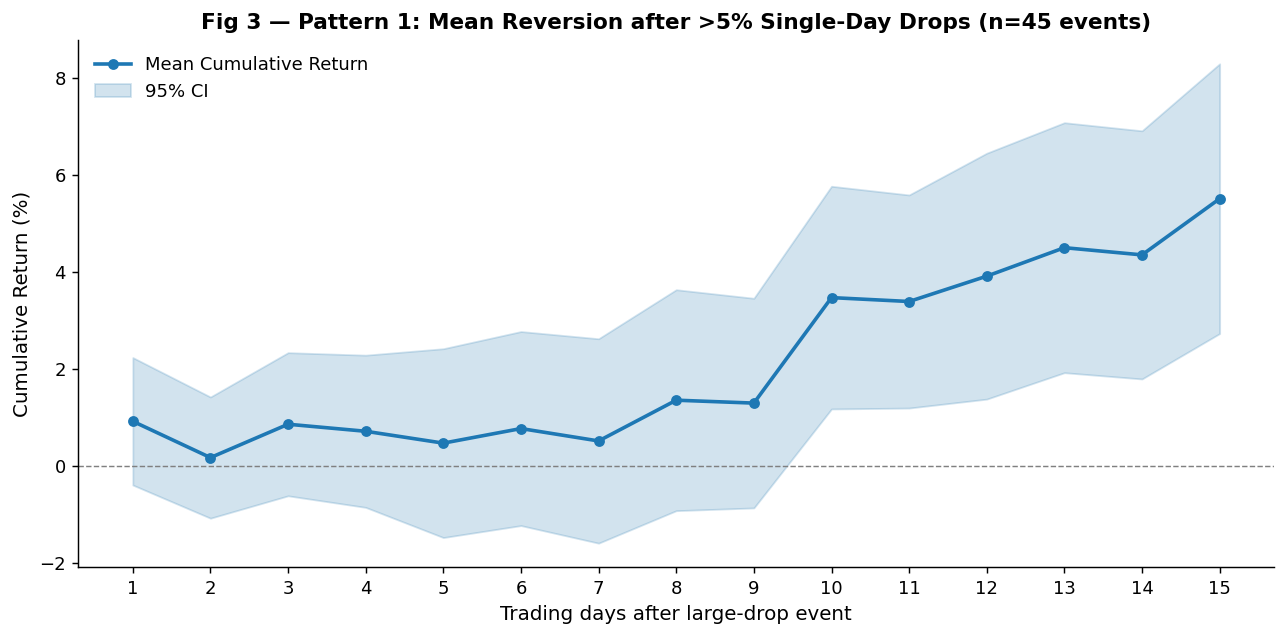

Saved: fig3_mean_reversion.png


In [7]:
# Plot mean cumulative return profile after event
fwd_cols = [f'T+{t}' for t in range(1, HORIZON+1)]
mean_profile = event_df[fwd_cols].mean()
std_profile  = event_df[fwd_cols].std()
se_profile   = std_profile / np.sqrt(len(event_df))

fig, ax = plt.subplots(figsize=(10, 5))
x = range(1, HORIZON+1)
ax.plot(x, mean_profile.values * 100, color="#1E78B4", lw=2,
        marker='o', markersize=5, label='Mean Cumulative Return')
ax.fill_between(x,
                (mean_profile - 1.96*se_profile).values * 100,
                (mean_profile + 1.96*se_profile).values * 100,
                alpha=0.2, color='#2176AE', label='95% CI')
ax.axhline(0, color='grey', lw=0.8, linestyle='--')
ax.set_xlabel("Trading days after large-drop event")
ax.set_ylabel("Cumulative Return (%)")
ax.set_title(f"Fig 3 — Pattern 1: Mean Reversion after >5% Single-Day Drops (n={len(event_df)} events)")
ax.legend(frameon=False)
ax.set_xticks(list(x))
plt.tight_layout()
plt.savefig("fig3_mean_reversion.png", bbox_inches='tight')
plt.show()
print("Saved: fig3_mean_reversion.png")

In [8]:
# Statistical significance test
for horizon in [5, 10, 15]:
    col = f'T+{horizon}'
    if col in event_df.columns:
        sample = event_df[col].dropna().values
        t_stat, p_val = stats.ttest_1samp(sample, 0)
        sig = "*" if p_val < 0.10 else ""
        print(f"T+{horizon:2d}: mean={sample.mean()*100:+.2f}%  "
              f"t={t_stat:.2f}  p={p_val:.3f} {sig}")

T+ 5: mean=+0.47%  t=0.47  p=0.637 
T+10: mean=+3.47%  t=2.96  p=0.005 *
T+15: mean=+5.51%  t=3.88  p=0.000 *


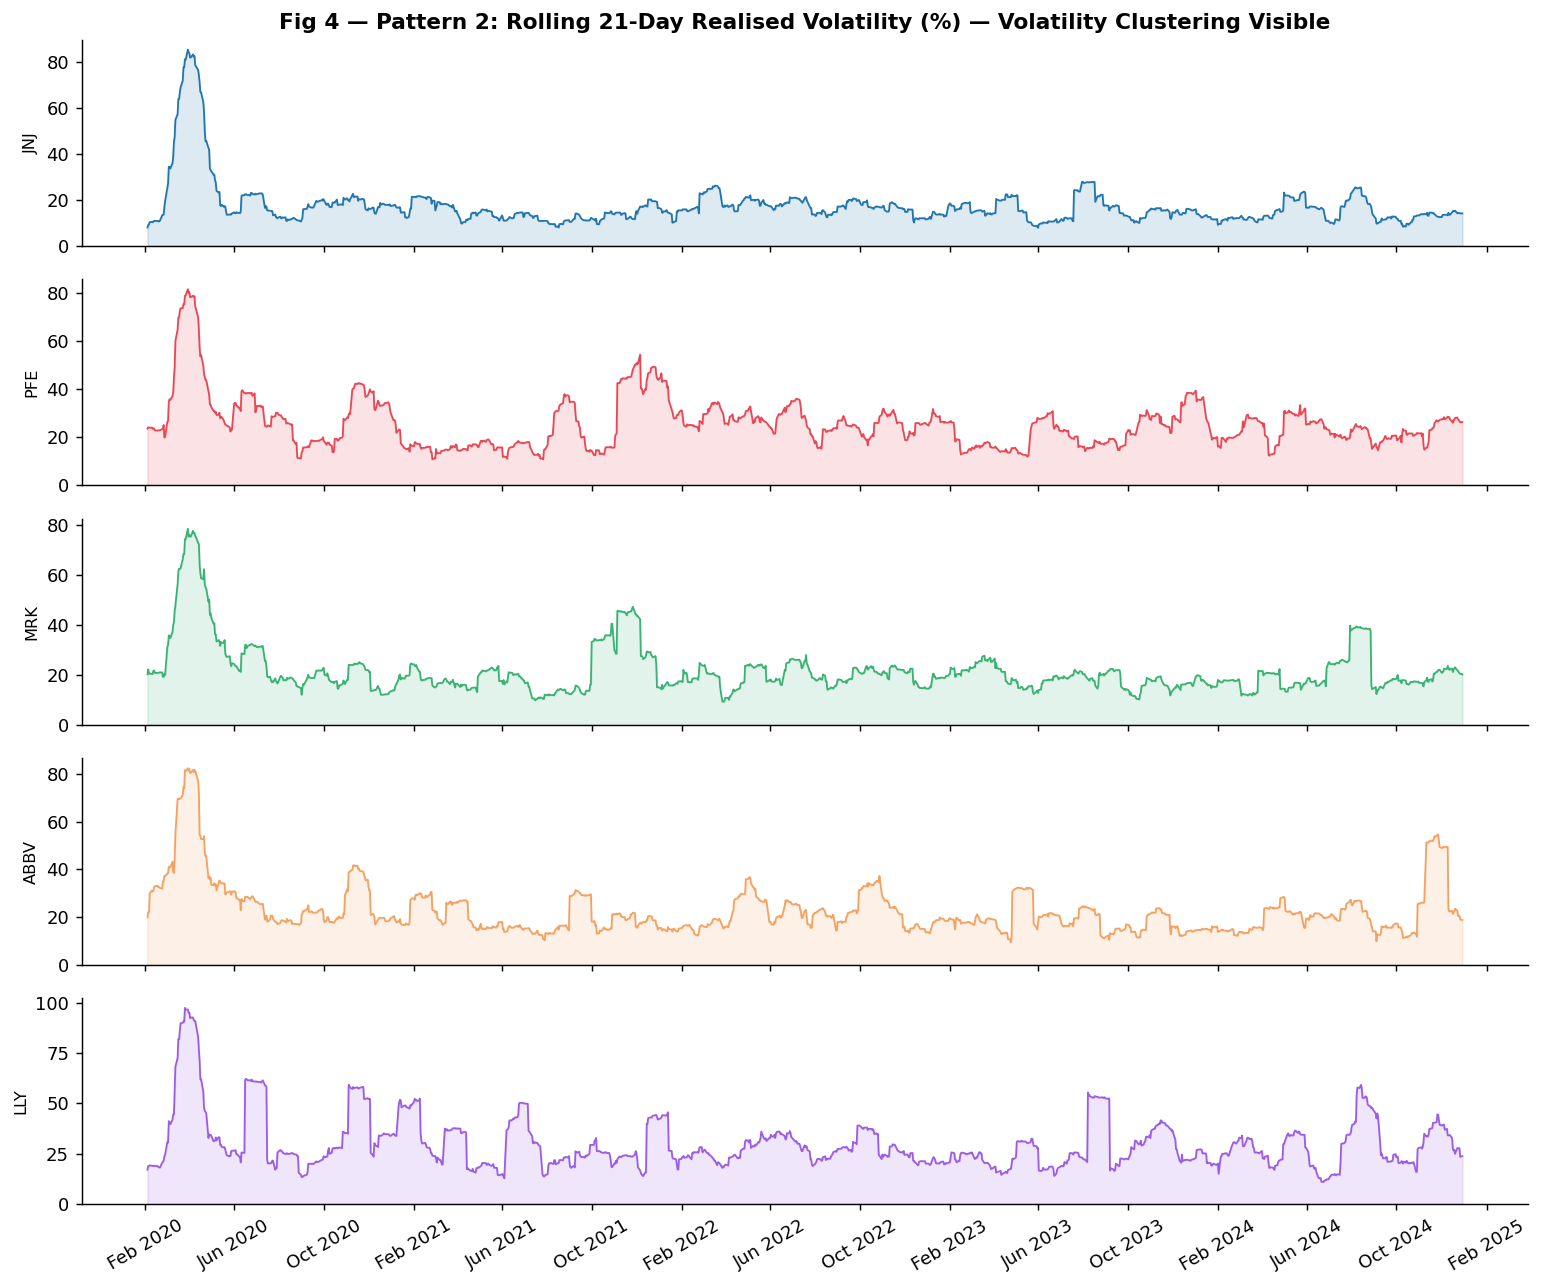

Saved: fig4_volatility_clustering.png

Autocorrelation of |daily returns| (lag 1–5):
JNJ: ['0.328', '0.329', '0.296', '0.308', '0.369']
PFE: ['0.183', '0.207', '0.179', '0.161', '0.169']
MRK: ['0.175', '0.184', '0.134', '0.143', '0.182']
ABBV: ['0.177', '0.182', '0.130', '0.140', '0.156']
LLY: ['0.119', '0.135', '0.108', '0.135', '0.091']


In [9]:
# ─── PATTERN 2: Volatility clustering ────────────────────────────── 

# Rolling 21-day realised volatility (annualised)
rvol = returns.rolling(21).std() * np.sqrt(252) * 100

fig, axes = plt.subplots(len(TICKERS), 1, figsize=(12, 10), sharex=True)
for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    ax.plot(rvol.index, rvol[ticker], color=TICKER_COLOR[ticker], lw=1)
    ax.fill_between(rvol.index, 0, rvol[ticker], alpha=0.15, color=TICKER_COLOR[ticker])
    ax.set_ylabel(ticker, fontsize=9)
    ax.set_ylim(0, None)

axes[0].set_title("Fig 4 — Pattern 2: Rolling 21-Day Realised Volatility (%) — Volatility Clustering Visible")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("fig4_volatility_clustering.png", bbox_inches='tight')
plt.show()
print("Saved: fig4_volatility_clustering.png")

# Autocorrelation in |returns| as evidence of clustering
print("\nAutocorrelation of |daily returns| (lag 1–5):")
for ticker in TICKERS:
    abs_r = returns[ticker].abs()
    acf_vals = [abs_r.autocorr(lag=k) for k in range(1, 6)]
    print(f"{ticker}: {[f'{v:.3f}' for v in acf_vals]}")

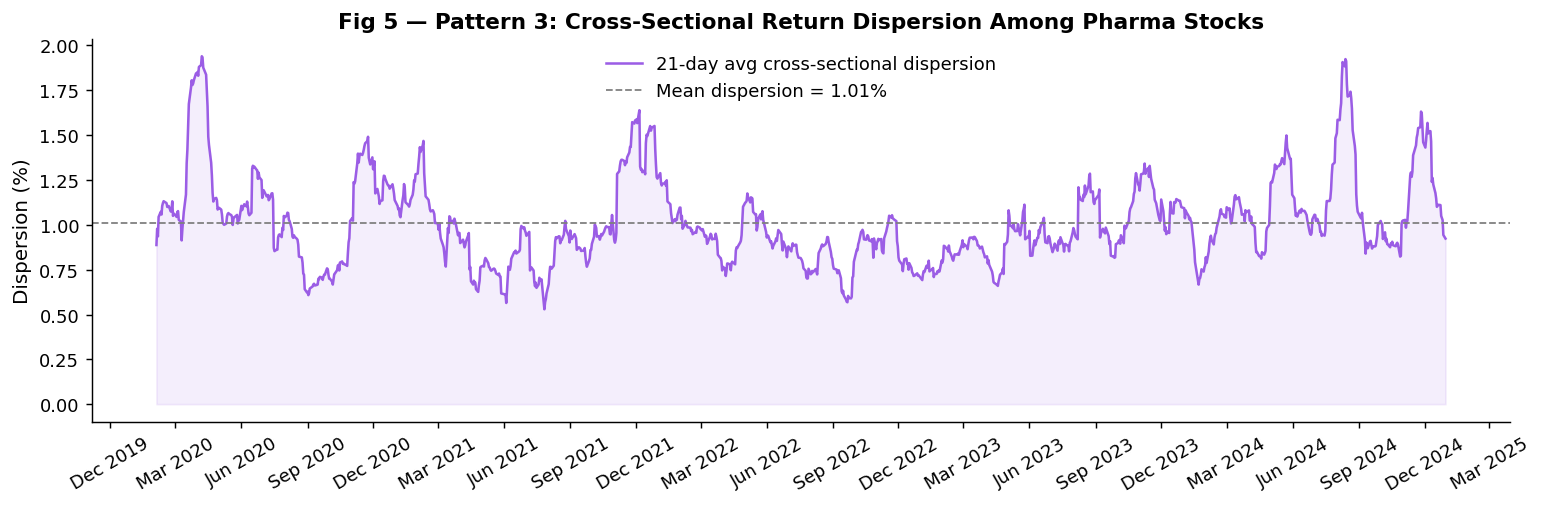

Saved: fig5_dispersion.png

Mean dispersion in HIGH-vol regime : 1.223%
Mean dispersion in LOW-vol regime  : 0.845%
=> Dispersion widens when sector volatility rises - individual stories dominate macro


In [ ]:
# ─── PATTERN 3: High intra-sector return dispersion ──────────────────────────────

# Cross-sectional dispersion: std dev of daily returns across the 5 stocks
cross_sec_disp = returns.std(axis=1).rolling(21).mean() * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(cross_sec_disp.index, cross_sec_disp.values,
        color='#9B5DE5', lw=1.4, label='21-day avg cross-sectional dispersion')
ax.fill_between(cross_sec_disp.index, 0, cross_sec_disp.values,
                alpha=0.1, color='#9B5DE5')
ax.axhline(cross_sec_disp.mean(), color='grey', lw=1, linestyle='--',
           label=f'Mean dispersion = {cross_sec_disp.mean():.2f}%')
ax.set_title("Fig 5 — Pattern 3: Cross-Sectional Return Dispersion Among Pharma Stocks")
ax.set_ylabel("Dispersion (%)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig5_dispersion.png", bbox_inches='tight')
plt.show()
print("Saved: fig5_dispersion.png")

# Dispersion in high-vol vs low-vol regimes
mkt_vol = rvol.mean(axis=1)
high_vol_mask = mkt_vol > mkt_vol.quantile(0.67)
low_vol_mask  = mkt_vol <= mkt_vol.quantile(0.33)
print(f"\nMean dispersion in HIGH-vol regime : {cross_sec_disp[high_vol_mask].mean():.3f}%")
print(f"Mean dispersion in LOW-vol regime  : {cross_sec_disp[low_vol_mask].mean():.3f}%")
print("=> Dispersion widens when sector volatility rises - individual stories dominate macro")

## 3. Trading / Risk Idea: Pharma Buy-the-Dip Strategy

**Hypothesis:** Large-cap pharma stocks that fall >5% in a single trading day - typically triggered by trial readouts, regulatory setbacks, or earnings misses - overreact in the short run. Buying after the shock and exiting at T+10 captures the mean reversion premium.

**Entry rule:** Open long on T+1 open after any day where a stock's return < –5%  
**Exit rule:** Close at end of T+10 (10 trading days after event)  
**Position sizing:** Equal notional per trade (1 unit)  
**Universe:** JNJ, PFE, MRK, ABBV, LLY (large-cap, high-liquidity only)

In [12]:
# ─── Backtest ─────────────────────────────────────────────────────────────────
ENTRY_OFFSET = 1    # enter at T+1 open (approximated as T+1 close in daily data)
EXIT_OFFSET  = 10   # hold for 10 trading days

trades = []
for ticker in TICKERS:
    r = returns[ticker]
    drop_days = r[r < THRESHOLD].index
    for event_day in drop_days:
        event_loc = returns.index.get_loc(event_day)
        entry_loc = event_loc + ENTRY_OFFSET
        exit_loc  = event_loc + EXIT_OFFSET
        if exit_loc >= len(returns):
            continue
        hold_returns = returns[ticker].iloc[entry_loc : exit_loc + 1].values
        trade_return = np.prod(1 + hold_returns) - 1
        trades.append({
            'ticker':        ticker,
            'event_date':    event_day,
            'event_return':  r[event_day],
            'entry_date':    returns.index[entry_loc],
            'exit_date':     returns.index[exit_loc],
            'trade_return':  trade_return
        })

trades_df = pd.DataFrame(trades)
print(f"Total trades: {len(trades_df)}")
print(trades_df[['ticker','event_date','event_return','trade_return']]
      .assign(event_return=lambda d: d.event_return.map('{:.2%}'.format),
              trade_return=lambda d: d.trade_return.map('{:.2%}'.format)).to_string(index=False))

covid_mask = pd.DatetimeIndex(trades_df['event_date']).year == 2020
covid_trades    = trades_df[covid_mask]['trade_return']
non_covid_trades = trades_df[~covid_mask]['trade_return']

print(f"COVID trades     (n={len(covid_trades)}):     mean={covid_trades.mean():.2%}  win rate={(covid_trades>0).mean():.0%}")
print(f"Non-COVID trades (n={len(non_covid_trades)}): mean={non_covid_trades.mean():.2%}  win rate={(non_covid_trades>0).mean():.0%}")

Total trades: 45
ticker event_date event_return trade_return
   JNJ 2020-03-11       -6.95%       -9.41%
   JNJ 2020-03-16       -5.33%        4.63%
   JNJ 2020-03-19       -5.86%        4.80%
   JNJ 2020-03-20       -5.64%       11.91%
   JNJ 2020-03-23       -7.30%       25.75%
   PFE 2020-01-28       -5.03%        0.89%
   PFE 2020-03-11       -7.00%       -7.52%
   PFE 2020-03-12       -6.68%        5.76%
   PFE 2020-03-16       -7.73%        8.25%
   PFE 2020-03-19       -6.00%        8.05%
   PFE 2020-06-01       -7.15%       -5.92%
   PFE 2020-06-11       -7.29%       -2.94%
   PFE 2020-10-28       -5.29%        9.72%
   PFE 2021-12-06       -5.14%       18.53%
   PFE 2023-12-01       -5.12%       -7.89%
   PFE 2023-12-13       -6.72%        7.99%
   MRK 2020-03-12       -6.06%       -0.42%
   MRK 2020-03-16       -8.90%       10.05%
   MRK 2020-03-23       -6.95%       20.95%
   MRK 2020-04-21       -5.46%       -0.70%
   MRK 2020-06-11       -5.41%       -0.22%
   MRK 2021-11-

In [ ]:
# ─── Performance metrics ──────────────────────────────────────────────────────
tr = trades_df['trade_return']

win_rate  = (tr > 0).mean()
avg_win   = tr[tr > 0].mean() if (tr > 0).any() else 0
avg_loss  = tr[tr < 0].mean() if (tr < 0).any() else 0
avg_return = tr.mean()
profit_factor = abs(avg_win / avg_loss) if avg_loss != 0 else np.inf

# Annualised Sharpe using daily equivalent
holding_days = EXIT_OFFSET
rf_per_trade = 0.045 * holding_days / 252
excess = tr - rf_per_trade
sharpe_approx = (excess.mean() / excess.std()) * np.sqrt(252 / holding_days) if excess.std() > 0 else 0

# Equity curve (equal-weight, sequential)
equity = (1 + tr).cumprod()
peak   = equity.cummax()
drawdown = (equity / peak - 1)
max_dd = drawdown.min()

print("═" * 45)
print("  Backtest Results — Buy-the-Dip Strategy")
print("═" * 45)
print(f"  Trades           : {len(tr)}")
print(f"  Win Rate         : {win_rate:.1%}")
print(f"  Avg Return/Trade : {avg_return:.2%}")
print(f"  Avg Win          : {avg_win:.2%}")
print(f"  Avg Loss         : {avg_loss:.2%}")
print(f"  Profit Factor    : {profit_factor:.2f}")
print(f"  Sharpe (approx.) : {sharpe_approx:.2f}")
print(f"  Max Drawdown     : {max_dd:.2%}")
print("-" * 45)